In [39]:
# import gensim.downloader as api

# # Download pretrained model.wv
# # Trained by Google on a large corpus of news articles
# # About 3 million words and phrases
# # Trained on roughly 100 billion words from Google News
# # Vector size = 300 dimensions
# # Around 1.5 GB in memory

# model = api.load("word2vec-google-news-300")

In [8]:
import tensorflow as tf 
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np



In [2]:
model = Sequential()
model.add(Dense(4, activation = 'relu', input_shape=(2,)))
model.add(Dense(3, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/Users/atharvsawant/Desktop/NLP/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
texts = [
    "I love this product.",
    "This movie is amazing.",
    "The food was delicious.",
    "I am very happy today.",
    "The service was excellent.",
    "I hate this product.",
    "This movie is boring.",
    "The food was terrible.",
    "I am very sad today.",
    "The service was bad."
]

labels = np.array([1,1,1,1,1,0,0,0,0,0])

In [12]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(texts)

text_vec = X.toarray()
print(text_vec)
print(tfidf.get_feature_names_out())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.6804329  0.
  0.57843013 0.         0.         0.         0.         0.44992184
  0.         0.         0.        ]
 [0.         0.58899657 0.         0.         0.         0.
  0.         0.         0.         0.5007009  0.         0.5007009
  0.         0.         0.         0.         0.         0.3894615
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.62051954 0.
  0.5274983  0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.4103054  0.
  0.         0.         0.4103054 ]
 [0.47761213 0.         0.         0.         0.         0.
  0.         0.56183624 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.47761213 0.47761213 0.        ]
 [0.         0.         0.         0.         0.         0.62051954
  0.         0.         0.         0.         

In [14]:
model = Sequential()
model.add(Dense(8,activation = 'relu', input_shape = (text_vec.shape[1],)))
model.add(Dense(1,activation = 'sigmoid'))

model.compile(
    optimizer ='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(text_vec, labels, epochs = 100, verbose =0)



In [16]:
new_texts = [
    "I want to work in AI and machine learning"]
new_vectors = tfidf.transform(new_texts).toarray()
predictions = model.predict(new_vectors)
print("Predicted probabilities for new texts:")
print(predictions)
 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted probabilities for new texts:
[[0.5287273]]


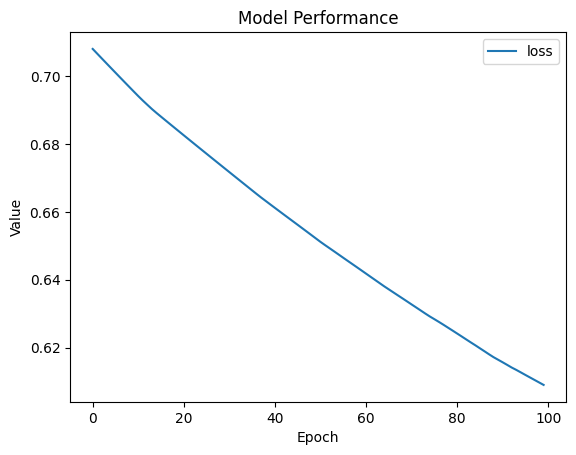

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()

class assignment


In [19]:
tokens = []
for i in texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    tokens.append(words)

print(tokens)

[['i', 'love', 'this', 'product'], ['this', 'movie', 'is', 'amazing'], ['the', 'food', 'was', 'delicious'], ['i', 'am', 'very', 'happy', 'today'], ['the', 'service', 'was', 'excellent'], ['i', 'hate', 'this', 'product'], ['this', 'movie', 'is', 'boring'], ['the', 'food', 'was', 'terrible'], ['i', 'am', 'very', 'sad', 'today'], ['the', 'service', 'was', 'bad']]


In [21]:
from gensim.models import Word2Vec
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)


In [22]:
sentence_vectors = []

for sentence in tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)
    sentence_vectors.append(sentence_vector)

new_word = np.array(sentence_vectors)

print(new_word.shape)

(10, 50)


In [27]:
# Function to convert sentence into vector
def get_sentence_vector(sentence):

    words = sentence.lower().split()

    vectors = []

    for word in words:
        if word in word_model.wv:
            vectors.append(word_model.wv[word])

    return np.mean(vectors, axis=0)

# Create X_word
X_word = np.array([
    get_sentence_vector(text)
    for text in texts
])

# Build model
model2 = Sequential()

model2.add(Dense(
    8,
    activation='relu',
    input_shape=(X_word.shape[1],)
))

model2.add(Dense(
    1,
    activation='sigmoid'
))

# Compile model
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model2.fit(
    X_word,
    labels,
    epochs=100,
    verbose=0
)

# Predict new text
new_text = "I want to work in AI and machine learning"

new_vector = np.array([
    get_sentence_vector(new_text)
])

prediction = model2.predict(new_vector)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Predicted Class: AI/Data Science")
else:
    print("Predicted Class: Other")

/Users/atharvsawant/Desktop/NLP/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prediction Score: 0.5009308
Predicted Class: AI/Data Science


In [28]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model2.fit(X_word,labels,epochs=100,verbose=0)
loss, accuracy = model2.evaluate(X_word, labels)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7000 - loss: 0.6846
Accuracy: 0.699999988079071


In [31]:
new_tokens = []
for i in new_texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    new_tokens.append(words)

print(new_tokens)

new_texts = [
    "I want to work in AI and machine learning"]



[['i', 'want', 'to', 'work', 'in', 'ai', 'and', 'machine', 'learning']]


In [32]:
word_model.build_vocab(new_tokens, update=True)

word_model.train(
    new_tokens,
    total_examples=len(new_tokens),
    epochs=100
)

new_sentence_vectors = []

for sentence in new_tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    new_sentence_vector = np.mean(word_vectors, axis=0)
    new_sentence_vectors.append(new_sentence_vector)

new_word = np.array(new_sentence_vectors)

print(new_word.shape)

(1, 50)


In [33]:
predictions = model2.predict(new_word)
print("Predicted probabilities for new texts:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted probabilities for new texts:
[[0.503343]]


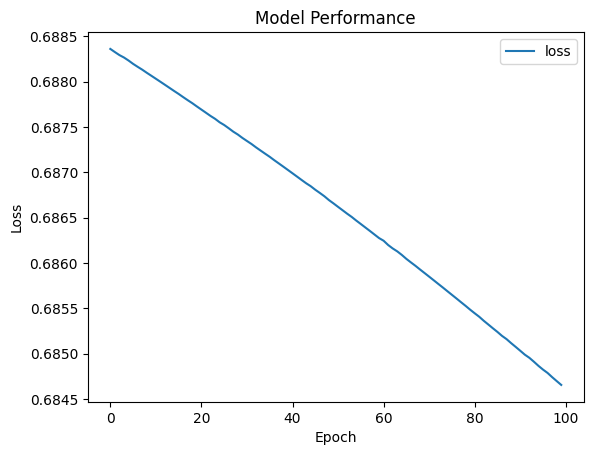

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Performance')

plt.legend()

plt.show()